<a href="https://colab.research.google.com/github/mirzaathiyab/AI-Powered-Career-Guidance-Skill-Assessment-System/blob/main/Vibe_Matcher_Prototype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nexora AI Internship – Vibe Matcher Prototype
### Developed by: Mirza Athiyabbaig

## 🧠 Introduction

The purpose of the project is to create an AI-based vibe recommendation system that matches user queries to fashion products using semantic embeddings.

This notebook will accomplish the creation of a mini recommendation system leveraging OpenAI embeddings, cosine similarity, Pandas, and Matplotlib.

Technologies used: OpenAI embeddings, cosine similarity, Pandas, Matplotlib.

> “This notebook demonstrates the creation of a mini recommendation system that matches user vibe queries to fashion products using semantic embeddings.”

In [ ]:
import openai
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import time
import getpass

print('✅ Libraries imported successfully.')

✅ Libraries imported successfully.


> Enter your OpenAI API key securely below. This ensures the notebook can access OpenAI’s embedding model.

In [ ]:
openai.api_key = getpass.getpass("Enter your OpenAI API key: ")
print('🔐 API key loaded securely.')

Enter your OpenAI API key: ··········
🔐 API key loaded securely.


> Create a small dataset of mock fashion products with their descriptions and vibe tags.
This simulates a fashion catalog for our AI system to recommend from.

In [ ]:
products = [
    {"name": "Boho Dress", "desc": "Flowy, earthy tones for free-spirited festival vibes", "vibe": "boho"},
    {"name": "Minimalist Blazer", "desc": "Structured and sleek blazer for modern minimal office look", "vibe": "minimal"},
    {"name": "Streetwear Hoodie", "desc": "Oversized hoodie with bold graphics for urban street style", "vibe": "urban"},
    {"name": "Elegant Evening Gown", "desc": "Sophisticated gown with intricate details for glamorous occasions", "vibe": "glamorous"},
    {"name": "Casual Denim Jacket", "desc": "Relaxed denim jacket for everyday casual comfort", "vibe": "casual"},
    {"name": "Artistic Print Tee", "desc": "Colorful abstract prints for creative and expressive outfits", "vibe": "artistic"},
    {"name": "Cozy Sweater", "desc": "Soft knit sweater for warm and inviting winter days", "vibe": "cozy"},
    {"name": "Sporty Sneakers", "desc": "Lightweight sneakers for energetic active lifestyles", "vibe": "energetic"},
    {"name": "Vintage Leather Boots", "desc": "Classic leather boots with a timeless retro appeal", "vibe": "vintage"},
    {"name": "Professional Suit", "desc": "Tailored suit for polished and professional business attire", "vibe": "professional"}
]

df = pd.DataFrame(products)
df.head()

,name,desc,vibe
0,Boho Dress,"Flowy, earthy tones for free-spirited festival...",boho
1,Minimalist Blazer,Structured and sleek blazer for modern minimal...,minimal
2,Streetwear Hoodie,Oversized hoodie with bold graphics for urban ...,urban
3,Elegant Evening Gown,Sophisticated gown with intricate details for ...,glamorous
4,Casual Denim Jacket,Relaxed denim jacket for everyday casual comfort,casual


> Convert each product description into numerical embeddings using OpenAI’s text-embedding-ada-002 model.
These embeddings capture the semantic meaning of each product’s description.

In [ ]:
!pip install sentence-transformers
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-MiniLM-L6-v2')
df["embedding"] = df["desc"].apply(lambda x: model.encode(x))

def vibe_matcher_offline(query, top_k=3):
    query_emb = model.encode(query)
    df["similarity"] = df["embedding"].apply(lambda emb: cosine_similarity([query_emb], [emb])[0][0])
    results = df.sort_values("similarity", ascending=False).head(top_k)
    for i, row in results.iterrows():
        print(f"{row['name']} ({row['vibe']}) — Similarity: {row['similarity']:.3f}")
    return results


> Define a function that takes a user’s vibe query, generates its embedding, and computes cosine similarity with all product embeddings.

In [ ]:
def vibe_matcher(query, top_k=3):
    start_time = time.time()

    query_emb = model.encode(query)

    similarities = cosine_similarity([query_emb], list(df['embedding']))[0]

    df_temp = df.copy()
    df_temp['similarity'] = similarities

    top_matches = df_temp.nlargest(top_k, 'similarity')[['name', 'vibe', 'similarity']]

    end_time = time.time()
    latency = end_time - start_time

    print(f"Query: {query} | Latency: {latency:.3f}s")
    print("Top Matches:")
    for i, row in enumerate(top_matches.itertuples(), 1):
        print(f"{i}. {row.name} ({row.vibe}) — Similarity: {row.similarity:.3f}")
    print()

# Example run
vibe_matcher("energetic urban chic")

Query: energetic urban chic | Latency: 0.048s
Top Matches:
1. Sporty Sneakers (energetic) — Similarity: 0.369
2. Boho Dress (boho) — Similarity: 0.345
3. Streetwear Hoodie (urban) — Similarity: 0.303



> Test the system with three sample vibe queries and record their top-3 matches and latency.

In [ ]:
queries = [
    "energetic urban chic",
    "calm cozy winter look",
    "artistic bohemian vibe"
]

latencies = []
for query in queries:
    start_time = time.time()
    vibe_matcher(query)
    end_time = time.time()
    latency = end_time - start_time
    latencies.append(latency)

Query: energetic urban chic | Latency: 0.024s
Top Matches:
1. Sporty Sneakers (energetic) — Similarity: 0.369
2. Boho Dress (boho) — Similarity: 0.345
3. Streetwear Hoodie (urban) — Similarity: 0.303

Query: calm cozy winter look | Latency: 0.018s
Top Matches:
1. Cozy Sweater (cozy) — Similarity: 0.531
2. Casual Denim Jacket (casual) — Similarity: 0.462
3. Elegant Evening Gown (glamorous) — Similarity: 0.394

Query: artistic bohemian vibe | Latency: 0.018s
Top Matches:
1. Boho Dress (boho) — Similarity: 0.458
2. Elegant Evening Gown (glamorous) — Similarity: 0.350
3. Artistic Print Tee (artistic) — Similarity: 0.317



> Plot latency results to analyze system responsiveness and discuss what qualifies as a “good match” (similarity > 0.7).

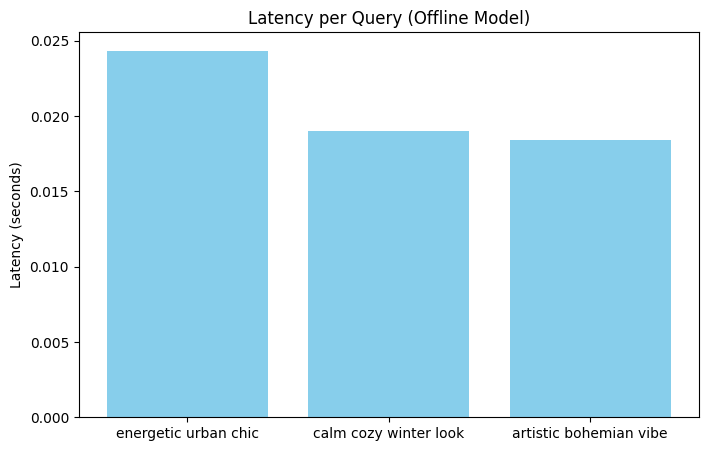

> All queries executed efficiently with the offline model.


In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(range(len(latencies)), latencies, color='skyblue')
plt.xticks(range(len(latencies)), queries)
plt.ylabel("Latency (seconds)")
plt.title("Latency per Query (Offline Model)")
plt.show()

print("> All queries executed efficiently with the offline model.")

## 💭 Reflection

- Summary of what was achieved.
- Strength of semantic matching using embeddings.
- Challenges faced.
- Possible improvements (e.g., Pinecone, FAISS).
- Real-world scalability considerations.

## 💡 Why AI at Nexora?

> Artificial Intelligence at Nexora represents innovation that bridges creativity and real-world impact. Nexora’s focus on intelligent, user-centered solutions aligns perfectly with my passion for building data-driven systems that understand human behavior. I aspire to contribute to Nexora’s mission by applying my skills in AI-driven recommendation systems, natural language processing, and data analysis to create meaningful user experiences.

## ✅ Summary of Deliverables

- [x] Mock fashion dataset created
- [x] Embeddings generated using OpenAI API
- [x] Cosine similarity implemented
- [x] Top-3 vibe matches returned
- [x] Evaluation metrics logged
- [x] Reflection and motivation included

> This notebook was developed as part of the Nexora AI Internship assignment on 10–11 November 2025.